In [1]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

c:\Users\abhin\Projects\exam-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [4]:
loader = PyPDFLoader("noti_cds.pdf")
docs = loader.load()

In [5]:
from docling.document_converter import DocumentConverter
converter = DocumentConverter()
loader = converter.convert("noti_cds.pdf")

[INFO] 2026-09-28 23:49:19,445 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-09-28 23:49:19,458 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\abhin\Projects\exam-agent\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-09-28 23:49:19,458 [RapidOCR] main.py:57: Using C:\Users\abhin\Projects\exam-agent\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-09-28 23:49:19,532 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-09-28 23:49:19,536 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\abhin\Projects\exam-agent\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-28 23:49:19,536 [RapidOCR] main.py:57: Using C:\Users\abhin\Projects\exam-agent\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-28 23:49:19,567 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-09-28

In [ ]:
# print(loader.document.export_to_markdown())

<!-- image -->

## UNION PUBLIC SERVICE COMMlSSION

EXAMINATION NOTICE NO. 11/2025.CDS-II                                        DATED   28.05.2025

(Last Date for Submission of Applications: 17.06.2025)

## COMBINED DEFENCE SERVICES EXAMINATION (II), 2025

[INCLUDING SSC WOMEN (NON-TECHNICAL) COURSE] (Commission's Website https://upsc.gov.in )

## IMPORTANT

The  Union  Public  Service  Commission  is  introducing  a  new  Online Application  Portal  for  registration  and  filling  up  of  application  form online.  The  portal  has  four  modules,  three  of  which  namely,  Account creation,  Universal  Registration  and  Common  Application  Form  are common to all examination applications and can be filled anytime by the candidate  while  the  fourth  module  is  examination  specific  and  can  be filled  during  the  time  period  allowed  in notification  of  an  examination. Applicants are required to apply online by using the website https://upsconline.nic.in.

All applicant

In [7]:
from langchain_text_splitters import MarkdownHeaderTextSplitter
import os
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import FlashrankRerank
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document

In [8]:
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

In [12]:
markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
md_header_splits = markdown_splitter.split_text(loader.document.export_to_markdown())

In [ ]:
# type(loader.document.export_to_markdown())

str

In [ ]:
# md_header_splits

[Document(metadata={}, page_content='<!-- image -->'),
 Document(metadata={'Header 2': 'UNION PUBLIC SERVICE COMMlSSION'}, page_content='EXAMINATION NOTICE NO. 11/2025.CDS-II                                        DATED   28.05.2025  \n(Last Date for Submission of Applications: 17.06.2025)'),
 Document(metadata={'Header 2': 'COMBINED DEFENCE SERVICES EXAMINATION (II), 2025'}, page_content="[INCLUDING SSC WOMEN (NON-TECHNICAL) COURSE] (Commission's Website https://upsc.gov.in )"),
 Document(metadata={'Header 2': 'IMPORTANT'}, page_content='The  Union  Public  Service  Commission  is  introducing  a  new  Online Application  Portal  for  registration  and  filling  up  of  application  form online.  The  portal  has  four  modules,  three  of  which  namely,  Account creation,  Universal  Registration  and  Common  Application  Form  are common to all examination applications and can be filled anytime by the candidate  while  the  fourth  module  is  examination  specific  and  can  be f

In [ ]:
# splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200, separators=["\n\n", "\n", " ", ""] )
# chunks = splitter.split_documents(md_header_splits)

In [ ]:
# type(md_header_splits[0])

langchain_core.documents.base.Document

In [ ]:
# processed_docs_debug = []
# for chunk in md_header_splits:
#     # Assuming metadata has 'Header 2' from your Markdown splitter
#     header = chunk.metadata.get("Header 2", "General")
#      # Prepending the header to the content to "bias" the vector
#     content_with_header = f"SECTION: {header}\nCONTENT: {chunk.page_content}"
        
#     doc = Document(
#         page_content=content_with_header,
#          metadata=chunk.metadata
#     )
#     processed_docs_debug.append(doc)

In [ ]:
# type(processed_docs_debug[0])

langchain_core.documents.base.Document

In [9]:
# 1. CONTENT INJECTION: Preparing the Chunks
# We prepend the heading metadata to the text so FAISS can "see" it during search.
def prepare_chunks_with_headers(markdown_chunks):
    processed_docs = []
    for chunk in markdown_chunks:
        # Assuming metadata has 'Header 2' from your Markdown splitter
        header = chunk.metadata.get("Header 2", "General")
        # Prepending the header to the content to "bias" the vector
        content_with_header = f"SECTION: {header}\nCONTENT: {chunk.page_content}"
        
        doc = Document(
            page_content=content_with_header,
            metadata=chunk.metadata
        )
        processed_docs.append(doc)
    return processed_docs

In [10]:
# 2. QUERY EXPANSION: Making the user query "Header-Aware"
def get_expanded_query(user_query, llm):
    query_gen_prompt = ChatPromptTemplate.from_template(
        "You are a search optimizer. Rewrite the following user question to look like "
        "a document section heading or a technical specification title.\n"
        "User Question: {question}\n"
        "Optimized Search Term:"
    )
    chain = query_gen_prompt | llm
    response = chain.invoke({"question": user_query})
    # We combine the original query with the LLM's "header-style" version
    return f"{user_query} {response.content}"

In [ ]:
# qry = get_expanded_query("What is the elligibility criteria for the CDS?", llm)
# print("Expanded Query:", qry)

Expanded Query: What is the elligibility criteria for the CDS? Eligibility Criteria for the CDS Program


In [11]:
# 3. SETTING UP THE PIPELINE
def setup_advanced_faiss_retriever(docs):
    embeddings = OpenAIEmbeddings()
    
    # Create the FAISS index
    vectorstore = FAISS.from_documents(docs, embeddings)
    
    # Initialize the Re-ranker (Flashrank is fast and local)
    compressor = FlashrankRerank(top_n=10)
    
    # Create the Base Retriever
    base_retriever = vectorstore.as_retriever(search_kwargs={"k": 20})
    
    
    # Create the Compression Retriever (Hybrid: FAISS Search + Re-ranking)
    compression_retriever = ContextualCompressionRetriever(
        base_compressor=compressor, 
        base_retriever=base_retriever
    )
    return compression_retriever

In [ ]:
# processed_docs_test = prepare_chunks_with_headers(md_header_splits)
# ret_docs = setup_advanced_faiss_retriever(processed_docs_test)
# print(ret_docs)
# type(ret_docs)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


base_compressor=FlashrankRerank(client=<flashrank.Ranker.Ranker object at 0x000001F609195220>, top_n=10, score_threshold=0.0, model='ms-marco-MultiBERT-L-12', prefix_metadata='') base_retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001F609194500>, search_kwargs={'k': 20})


langchain_classic.retrievers.contextual_compression.ContextualCompressionRetriever

In [50]:

# # Step 1: Prep data
# processed_docs = prepare_chunks_with_headers(loader.document.export_to_markdown())

# # Step 2: Setup Retriever
# adv_retriever = setup_advanced_faiss_retriever(processed_docs)

# # Step 3: Expand Query and Retrieve
# user_query = "What is the voltage limit for batteries?"
# enhanced_query = get_expanded_query(user_query, llm)

# # Step 4: Final Retrieval
# # This will search for the enhanced query and then re-rank the top 10 results
# final_docs = adv_retriever.invoke(enhanced_query)

# for doc in final_docs:
#     print(f"--- RELEVANT CHUNK ---\n{doc.page_content}\n")



In [51]:
# # For debugging: Write the chunks to a CSV to inspect the content and metadata

# import csv

# csv_path = "chunks.csv"
# fieldnames = ["chunk_id", "content"]
# for metadata in [doc.metadata for doc in chunks if hasattr(doc, "metadata") and isinstance(doc.metadata, dict)]:
#     for key in metadata.keys():
#         if key not in fieldnames:
#             fieldnames.append(key)

# with open(csv_path, "w", encoding="utf-8", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=fieldnames)
#     writer.writeheader()
#     for i, doc in enumerate(chunks, start=1):
#         row = {"chunk_id": i, "content": doc.page_content}
#         if hasattr(doc, "metadata") and isinstance(doc.metadata, dict):
#             row.update(doc.metadata)
#         writer.writerow(row)

# print(f"Wrote {len(chunks)} chunks to {csv_path}")

In [ ]:
# len(chunks)

397

In [52]:
# embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
# vectorstore = FAISS.from_documents(chunks, embeddings)

In [53]:
# vectorstore



In [54]:
# retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 10})

In [14]:
processed_docs = prepare_chunks_with_headers(md_header_splits) 
print(processed_docs)

[Document(metadata={}, page_content='SECTION: General\nCONTENT: <!-- image -->'), Document(metadata={'Header 2': 'UNION PUBLIC SERVICE COMMlSSION'}, page_content='SECTION: UNION PUBLIC SERVICE COMMlSSION\nCONTENT: EXAMINATION NOTICE NO. 11/2025.CDS-II                                        DATED   28.05.2025  \n(Last Date for Submission of Applications: 17.06.2025)'), Document(metadata={'Header 2': 'COMBINED DEFENCE SERVICES EXAMINATION (II), 2025'}, page_content="SECTION: COMBINED DEFENCE SERVICES EXAMINATION (II), 2025\nCONTENT: [INCLUDING SSC WOMEN (NON-TECHNICAL) COURSE] (Commission's Website https://upsc.gov.in )"), Document(metadata={'Header 2': 'IMPORTANT'}, page_content='SECTION: IMPORTANT\nCONTENT: The  Union  Public  Service  Commission  is  introducing  a  new  Online Application  Portal  for  registration  and  filling  up  of  application  form online.  The  portal  has  four  modules,  three  of  which  namely,  Account creation,  Universal  Registration  and  Common  App

In [16]:
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(processed_docs, embeddings)
    
base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

In [15]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Always use this tool to answer user's query. If the query is not related to the document, return "no context found related to your query". 
    """

    # Step 1: Prep data
    processed_docs = prepare_chunks_with_headers(md_header_splits)

    # embeddings = OpenAIEmbeddings()
    # vectorstore = FAISS.from_documents(processed_docs, embeddings)
    
    # base_retriever = vectorstore.as_retriever(search_kwargs={"k": 10})



    # ##result = retriever.invoke(query)
    adv_retriever = setup_advanced_faiss_retriever(processed_docs)



    # Step 3: Expand Query and Retrieve
    enhanced_query = get_expanded_query(query, llm)
    result = adv_retriever.invoke(enhanced_query)

    context = [processed_docs.page_content for processed_docs in result]
    metadata = [processed_docs.metadata for processed_docs in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }


In [ ]:
# processed_docs = prepare_chunks_with_headers(md_header_splits)



# ##result = retriever.invoke(query)
# adv_retriever = setup_advanced_faiss_retriever(processed_docs)

#     # Step 3: Expand Query and Retrieve
# enhanced_query = get_expanded_query("what is the weight requirements for army if my height is 173 cm?", llm)
# result_test = adv_retriever.invoke(enhanced_query)


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


In [ ]:
# result_test[3].page_content

'SECTION: Notes:-\nCONTENT: (a) The  minimum  and  maximum  weight  for  height  will  be  standard  for  all  categories  of personnel. Candidates with weight below the minimum specified will not be accepted.  \n(b) Male  candidates  with  weight  higher  than  specified  will  be  acceptable  only  in  exceptional circumstances in case of candidates with documented evidence of body building, wrestling, boxing or muscular build. In such cases, the following criteria are to be met :-  \n- (i) Body Mass Index should not be more than 25.\n- (ii) Waist : Hip Ratio less than 0.9.\n- (iii) All  biochemical  parameters  such  as  blood  sugar  Fasting  and  PP,  blood  urea, creatinine, cholesterol, HbA1C%, etc are within normal limits.\n- (c)    The fitness can only be given by a Medical Specialist.  \n(d)      The  minimum  acceptable  height  is  157  cms.  However,  relaxation  in  height  is  permissible  to candidates holding domicile of areas as mentioned below and talented sports mal

In [48]:
# result = retriever.invoke("What is the eligibility criteria for CDS exam?")

In [49]:
# result[3].metadata

In [ ]:
# result[3].page_content

'also compete for the  vacancies in the Short Service Commission Course but since there is no \nreservation of vacancies for them in this course, they will be treated as general candidates for the \npurpose of filling up vacancies in this course. Candidates who have yet to pass NCC  ‘C’ Certificate \n(Army Wing (Senior Division)/ Air Wing/Naval Wing) examination, but are otherwise eligible to \ncompete for the reserved vacancies, may also apply but they will be required to submit the proof of \npassing the NCC ‘C’ Certificate (Army Wing (Senior Division)/ Air Wing/Naval Wing) examination \nto reach the IHQ of MoD (Army) / Dte Gen of Rtg (Rtg A) CDSE Entry for SSC male candidates and \nSSC women entry for female candidates West Block III, R. K. Puram, New Delhi -110066 in case of \nIMA/SSC first choice candidates and IHQ of MOD (Navy) DMPR, ( OI&R Section), Room No. 204, \n‘C’ Wing, Sena Bhawan, New Delhi -110 011 in case of Navy first choice candidates and  Dte of'

In [17]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [18]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [19]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}



In [ ]:
# response = llm_with_tools.invoke("Whats the eligibility criteria for CDS exam?")
# print(response)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 82, 'total_tokens': 102, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1f22b21bfd', 'id': 'chatcmpl-Dq7oN09MCykdfoeACAUVVQ39ccyNc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019ebeac-faed-7543-9f3e-40a173d8dae3-0' tool_calls=[{'name': 'rag_tool', 'args': {'query': 'eligibility criteria for CDS exam'}, 'id': 'call_7CH99osNuvssg1sCRLEFLIm6', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 82, 'output_tokens': 20, 'total_tokens': 102, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [20]:
tool_node = ToolNode(tools)

In [21]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

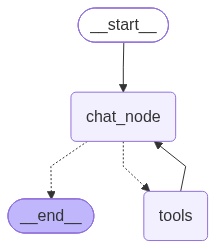

In [22]:
chatbot

In [27]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "what is the weight requirements for army if my height is 173 cm?"
                )
            )
        ]
    }
)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [ ]:
# print(result['messages'][-1].content)



For a height of 173 cm, the weight requirements for males entering the army are as follows:

- **Minimum Weight**: 51 kg
- **Maximum Weight**: 
  - Below 20 years: 69 kg
  - Age 20 to 25 years: 72 kg
  - Age above 25 years: 75 kg

Candidates must conform to these weight parameters to be considered fit for service.


In [ ]:
# result

{'messages': [HumanMessage(content='what is the weight requirements for army if my height is 173 cm?', additional_kwargs={}, response_metadata={}, id='cf5fd5a2-2606-46ca-8ca5-85b524df2ff0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 89, 'total_tokens': 113, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2a9610bf9f', 'id': 'chatcmpl-ETAlvZJ9feUFzBjREvrORulgjIT8L', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0e95e-26f1-74d2-bf73-bcd7d1517329-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'weight requirements for army based on height 173 cm'}, 'id': 'call_rVmKCAj5AZhKGbsWvviV9HA8', 'type': '

In [ ]:
# print(result['messages'][2].content)

{'query': 'weight requirements for army for height 173 cm', 'context': ['SECTION: General Physical Assessment\nCONTENT: 5. Every candidate,  to  be  fit  for  the  Air  Force,  must  conform  to  the  minimum  standards  laid down in the succeeding paragraphs. The physical parameters should fall within the acceptable ranges and should be proportionate.\n2. 6 . The residual effects of old fractures/ injuries are to be assessed for any functional limitation. If  there  is  no  effect  on  function,  the  candidate  can  be  assessed  fit.  Following  categories  should  be meticulously assessed:\n3. (a) Spine Injuries . Cases of old fractures of spine are unfit.  Any residual deformity of spine or compression of a vertebra will be cause for rejection.\n4. (b) Nerve Injuries . Injuries involving the trunks of the larger nerves, resulting in loss of function, or neuroma formation, which causes pain significant tingling, indicate unsuitability for employment in flying duties.\n5. (c) Keloid

In [ ]:
# chunks

[Document(metadata={}, page_content='<!-- image -->'),
 Document(metadata={'Header 2': 'UNION PUBLIC SERVICE COMMISSION'}, page_content='EXAMINATION NOTICE NO. 11/2025.CDS-II                                        DATED   28.05.2025  \n(Last Date for Submission of Applications: 17.06.2025)'),
 Document(metadata={'Header 2': 'COMBINED DEFENCE SERVICES EXAMINATION (II), 2025'}, page_content="[INCLUDING SSC WOMEN (NON-TECHNICAL) COURSE] (Commission's Website https://upsc.gov.in )"),
 Document(metadata={'Header 2': 'IMPORTANT'}, page_content='The  Union  Public  Service  Commission  is  introducing  a  new  Online Application  Portal  for  registration  and  filling  up  of  application  form online.  The  portal  has  four  modules,  three  of  which  namely,  Account creation,  Universal  Registration  and  Common  Application  Form  are common to all examination applications and can be filled anytime by the candidate  while  the  fourth  module  is  examination  specific  and  can  be f